## Fase 2 - entrenamiento final y evaluacion sobre test (U-Net STL, disease)

U-Net autoencoder completo (encoder + decoder), una sola fase, entrenada desde cero. Se usa la particion train/val/test original: se entrena con **train**, se monitoriza con **val** (early stopping y reduccion de LR) y se evalua una sola vez sobre **test**.

El modelo tiene dos salidas `[reconstruccion, clasificacion]`; las predicciones de clase se toman de la segunda. El balanceo de clases va por `sample_weight` (con dos salidas Keras no admite `class_weight`). Salidas: metricas finales sobre test y CSV de predicciones imagen a imagen para el estudio estadistico.

In [1]:
import os
import json
import time
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    balanced_accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, precision_score, recall_score,
    f1_score, cohen_kappa_score,
)

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

train_csv  = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/train_onehot.csv"
val_csv    = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/val_onehot.csv"
test_csv   = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/test_onehot.csv"
images_dir = "/home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/images"

IMG_SIZE    = (256, 256)
BATCH_SIZE  = 16
NUM_CLASSES = 7
TASK_NAME   = "disease"
class_cols  = ["dx_akiec", "dx_bcc", "dx_bkl", "dx_df", "dx_mel", "dx_nv", "dx_vasc"]
class_names = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

EPOCHS  = 60
LR_INIT = 5e-4

EXP_DIR = Path("UNet_STL") / f"exp_{dt.datetime.now():%Y-%m-%d_%H-%M}_disease_FASE2_final"
EXP_DIR.mkdir(parents=True, exist_ok=True)
print(f"Experimento fase 2 (U-Net) en: {EXP_DIR}")

2026-06-23 00:40:30.268312: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudart.so.10.1


Experimento fase 2 (U-Net) en: UNet_STL/exp_2026-06-23_00-40_disease_FASE2_final


In [2]:
# Particion original train / val / test
df_train = pd.read_csv(train_csv)
df_val   = pd.read_csv(val_csv)
df_test  = pd.read_csv(test_csv)
for df in (df_train, df_val, df_test):
    df["filepath"] = df["image_id"].apply(lambda x: os.path.join(images_dir, f"{x}.jpg"))

y_train = df_train[class_cols].values.astype("float32")
y_val   = df_val[class_cols].values.astype("float32")
y_test  = df_test[class_cols].values.astype("float32")
y_test_int = np.argmax(y_test, axis=1)

print(f"train: {len(df_train)}   val: {len(df_val)}   test: {len(df_test)}")


def load_image(filepath, y):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, {"reconstruction_output": img, "head_disease": y}


def make_dataset(filepaths, y):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, y))
    ds = ds.map(load_image, num_parallel_calls=15)
    return ds.batch(BATCH_SIZE).prefetch(50)


def make_dataset_weighted(filepaths, y, class_weight_arr, training=False):
    # sample_weight en la rama de clasificacion (balanceo). Reconstruccion peso 1.0.
    y_int = np.argmax(y, axis=1)
    sw    = class_weight_arr[y_int].astype("float32")

    def _load(filepath, label, sw_dis, training_flag):
        img = tf.io.read_file(filepath)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32)
        if training_flag:
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_flip_up_down(img)
            img = tf.image.random_brightness(img, max_delta=0.2)
            img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
            img = tf.clip_by_value(img, 0.0, 255.0)
        img = img / 255.0
        targets  = {"reconstruction_output": img, "head_disease": label}
        sample_w = {"reconstruction_output": tf.constant(1.0, dtype=tf.float32),
                    "head_disease": sw_dis}
        return img, targets, sample_w

    ds = tf.data.Dataset.from_tensor_slices((filepaths, y, sw))
    if training:
        ds = ds.shuffle(buffer_size=len(filepaths), reshuffle_each_iteration=True)
    ds = ds.map(lambda f, l, s: _load(f, l, s, training), num_parallel_calls=15)
    return ds.batch(BATCH_SIZE).prefetch(50)


test_ds = make_dataset(df_test["filepath"].values, y_test)

train: 6008   val: 2003   test: 2003


2026-06-23 00:40:31.323683: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcuda.so.1
2026-06-23 00:40:31.345592: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1716] Found device 0 with properties: 
pciBusID: 0000:05:00.0 name: GeForce GTX 1080 Ti computeCapability: 6.1
coreClock: 1.582GHz coreCount: 28 deviceMemorySize: 10.91GiB deviceMemoryBandwidth: 451.17GiB/s
2026-06-23 00:40:31.345622: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudart.so.10.1
2026-06-23 00:40:31.347000: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcublas.so.10
2026-06-23 00:40:31.348228: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcufft.so.10
2026-06-23 00:40:31.348416: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcurand.so

In [3]:
def encoder_block(inputs, num_filters):
    x = tf.keras.layers.Conv2D(num_filters, 3, activation="relu", padding="same",
                               kernel_initializer="he_normal")(inputs)
    x = tf.keras.layers.Conv2D(num_filters, 3, activation="relu", padding="same",
                               kernel_initializer="he_normal")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    p = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)(x)
    return x, p


def decoder_block(inputs, skip_features, num_filters):
    up = tf.keras.layers.UpSampling2D(size=(2, 2))(inputs)
    x  = tf.keras.layers.Conv2D(num_filters, 2, activation="relu", padding="same",
                                kernel_initializer="he_normal")(up)
    x = tf.keras.layers.concatenate([skip_features, x], axis=3)
    x = tf.keras.layers.Conv2D(num_filters, 3, activation="relu", padding="same",
                               kernel_initializer="he_normal")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(num_filters, 3, activation="relu", padding="same",
                               kernel_initializer="he_normal")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    return x


def build_model():
    inputs = tf.keras.layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name="input_image")
    c1, p1 = encoder_block(inputs, 64)
    c2, p2 = encoder_block(p1, 128)
    c3, p3 = encoder_block(p2, 256)
    c4, p4 = encoder_block(p3, 512)
    b1 = tf.keras.layers.Conv2D(1024, 3, activation="relu", padding="same",
                                kernel_initializer="he_normal")(p4)
    b1 = tf.keras.layers.BatchNormalization()(b1)
    b1 = tf.keras.layers.Conv2D(1024, 3, activation="relu", padding="same",
                                kernel_initializer="he_normal", name="bottleneck_conv")(b1)
    b1 = tf.keras.layers.BatchNormalization(name="bottleneck_bn")(b1)
    e1 = decoder_block(b1, c4, 512)
    e2 = decoder_block(e1, c3, 256)
    e3 = decoder_block(e2, c2, 128)
    e4 = decoder_block(e3, c1, 64)
    final_recon = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same",
                                         kernel_initializer="he_normal")(e4)
    final_recon = tf.keras.layers.BatchNormalization()(final_recon)
    reconstruction_output = tf.keras.layers.Conv2D(3, 1, activation="relu", padding="same",
                                                   name="reconstruction_output")(final_recon)
    x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(b1)
    shared = tf.keras.layers.Dense(256, activation="relu", name="shared_dense")(x)
    shared = tf.keras.layers.Dropout(0.3, name="shared_dropout")(shared)
    out_disease = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", name="head_disease")(shared)
    return tf.keras.Model(inputs, [reconstruction_output, out_disease],
                          name="STL_UNet_disease_autoencoder")

In [4]:
# Class weights balanceados sobre train (se aplican via sample_weight)
y_train_int = np.argmax(y_train, axis=1)
cw = compute_class_weight(class_weight="balanced",
                          classes=np.arange(NUM_CLASSES), y=y_train_int)
print(f"class weights: {cw.round(3)}")

train_ds = make_dataset_weighted(df_train["filepath"].values, y_train, cw, training=True)
val_ds   = make_dataset_weighted(df_val["filepath"].values,   y_val,   cw, training=False)

model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_INIT),
    loss={"reconstruction_output": "mse", "head_disease": "categorical_crossentropy"},
    loss_weights={"reconstruction_output": 0.2, "head_disease": 0.8},
    metrics={"head_disease": "accuracy"},
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=7, min_delta=0.005,
                                     restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3,
                                         min_lr=1e-7, verbose=1),
]
print(f"Entrenamiento U-Net autoencoder (LR={LR_INIT}, max_epochs={EPOCHS})")
t0 = time.time()
h = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=2)
t_train = time.time() - t0

pd.DataFrame(h.history).to_csv(EXP_DIR / "history.csv", index=False)
model.save_weights(str(EXP_DIR / "final_weights"), save_format="tf")

class weights: [ 4.379  2.787  1.3   12.439  1.285  0.213 10.097]
Entrenamiento U-Net autoencoder (LR=0.0005, max_epochs=60)
Epoch 1/60


2026-06-23 00:40:34.730673: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcublas.so.10
2026-06-23 00:40:35.109213: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudnn.so.7


376/376 - 369s - loss: 1.7742 - reconstruction_output_loss: 0.0324 - head_disease_loss: 2.2096 - head_disease_accuracy: 0.2931 - val_loss: 1.5379 - val_reconstruction_output_loss: 0.0216 - val_head_disease_loss: 1.9170 - val_head_disease_accuracy: 0.4983
Epoch 2/60
376/376 - 365s - loss: 1.5179 - reconstruction_output_loss: 0.0139 - head_disease_loss: 1.8939 - head_disease_accuracy: 0.3021 - val_loss: 2.4107 - val_reconstruction_output_loss: 0.0167 - val_head_disease_loss: 3.0093 - val_head_disease_accuracy: 0.5612
Epoch 3/60
376/376 - 363s - loss: 1.3450 - reconstruction_output_loss: 0.0119 - head_disease_loss: 1.6783 - head_disease_accuracy: 0.3477 - val_loss: 1.3181 - val_reconstruction_output_loss: 0.0143 - val_head_disease_loss: 1.6441 - val_head_disease_accuracy: 0.5127
Epoch 4/60
376/376 - 364s - loss: 1.2469 - reconstruction_output_loss: 0.0112 - head_disease_loss: 1.5559 - head_disease_accuracy: 0.3958 - val_loss: 1.9312 - val_reconstruction_output_loss: 0.0657 - val_head_dise

              precision    recall  f1-score   support

       akiec     0.2922    0.6818    0.4091        66
         bcc     0.3826    0.5534    0.4524       103
         bkl     0.4511    0.4840    0.4670       219
          df     0.1038    0.4783    0.1705        23
         mel     0.3144    0.6457    0.4229       223
          nv     0.9620    0.6048    0.7427      1341
        vasc     0.3966    0.8214    0.5349        28

    accuracy                         0.5976      2003
   macro avg     0.4147    0.6099    0.4571      2003
weighted avg     0.7644    0.5976    0.6415      2003



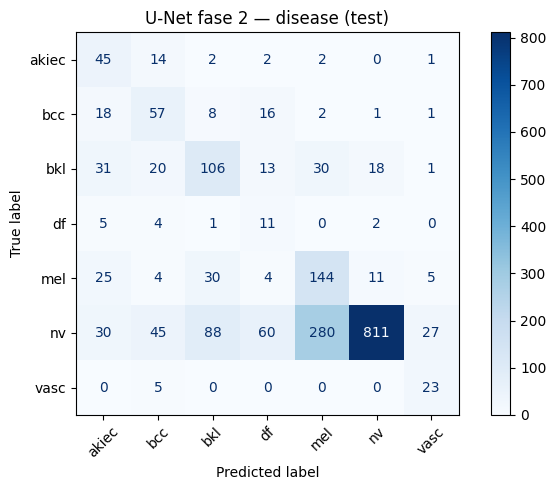


F1 macro test: 0.4571   balanced acc: 0.6099


In [5]:

preds        = model.predict(test_ds, verbose=0)
y_pred_proba = preds[1]
y_pred_int   = np.argmax(y_pred_proba, axis=1)

metrics = {
    "model":                   "UNet",
    "disease_acc":             float((y_test_int == y_pred_int).mean()),
    "disease_balanced_acc":    float(balanced_accuracy_score(y_test_int, y_pred_int)),
    "disease_precision_macro": float(precision_score(y_test_int, y_pred_int, average="macro", zero_division=0)),
    "disease_recall_macro":    float(recall_score(y_test_int, y_pred_int, average="macro", zero_division=0)),
    "disease_f1_macro":        float(f1_score(y_test_int, y_pred_int, average="macro", zero_division=0)),
    "disease_f1_weighted":     float(f1_score(y_test_int, y_pred_int, average="weighted", zero_division=0)),
    "disease_kappa":           float(cohen_kappa_score(y_test_int, y_pred_int)),
    "epochs_trained":          len(h.history["loss"]),
    "time_train_s":            round(t_train, 1),
}
try:
    metrics["disease_auc_macro"] = float(roc_auc_score(
        np.eye(NUM_CLASSES)[y_test_int], y_pred_proba, multi_class="ovr", average="macro"))
except Exception:
    metrics["disease_auc_macro"] = float("nan")
metrics["auc_melanoma"] = float(roc_auc_score((y_test_int == 4).astype(int), y_pred_proba[:, 4]))

(EXP_DIR / "metrics_FASE2.json").write_text(json.dumps(metrics, indent=2))
pd.DataFrame([metrics]).to_csv(EXP_DIR / "metrics_FASE2.csv", index=False)

rpt = classification_report(y_test_int, y_pred_int, target_names=class_names, digits=4)
(EXP_DIR / "classification_report_disease.txt").write_text(rpt)
print(rpt)

cm = confusion_matrix(y_test_int, y_pred_int)
np.save(EXP_DIR / "confusion_matrix_disease.npy", cm)
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True)
ax.set_title("U-Net fase 2 - disease (test)")
plt.tight_layout(); plt.savefig(EXP_DIR / "confusion_matrix_disease.png", dpi=120); plt.show()

print(f"\nF1 macro test: {metrics['disease_f1_macro']:.4f}   "
      f"balanced acc: {metrics['disease_balanced_acc']:.4f}")

In [6]:
# CSV de predicciones imagen a imagen (entrada del estudio estadistico)
df_pred = pd.DataFrame({
    "image_id":   df_test["image_id"].values,
    "true_label": [class_names[i] for i in y_test_int],
    "pred_label": [class_names[i] for i in y_pred_int],
    "true_idx":   y_test_int,
    "pred_idx":   y_pred_int,
})
for j, c in enumerate(class_names):
    df_pred[f"prob_{c}"] = y_pred_proba[:, j]

out_csv = EXP_DIR / "predictions_STL_UNet_disease_FASE2.csv"
df_pred.to_csv(out_csv, index=False)
print(f"CSV imagen a imagen guardado en:\n  {out_csv}")
print(df_pred.head())

CSV imagen a imagen guardado en:
  UNet_STL/exp_2026-06-23_00-40_disease_FASE2_final/predictions_STL_UNet_disease_FASE2.csv
       image_id true_label pred_label  true_idx  pred_idx  prob_akiec  \
0  ISIC_0028963         nv         nv         5         5    0.021212   
1  ISIC_0028197        bcc        bcc         1         1    0.270083   
2  ISIC_0028464         nv        bkl         5         2    0.038038   
3  ISIC_0028002         nv        bkl         5         2    0.111849   
4  ISIC_0024568         nv         nv         5         5    0.000002   

   prob_bcc  prob_bkl   prob_df  prob_mel   prob_nv  prob_vasc  
0  0.031711  0.128555  0.012242  0.281611  0.517133   0.007536  
1  0.317979  0.086250  0.195207  0.044547  0.083911   0.002024  
2  0.056141  0.419952  0.032480  0.169022  0.277626   0.006741  
3  0.038538  0.304848  0.201750  0.037709  0.304659   0.000646  
4  0.000026  0.001460  0.000497  0.000068  0.994317   0.003631  


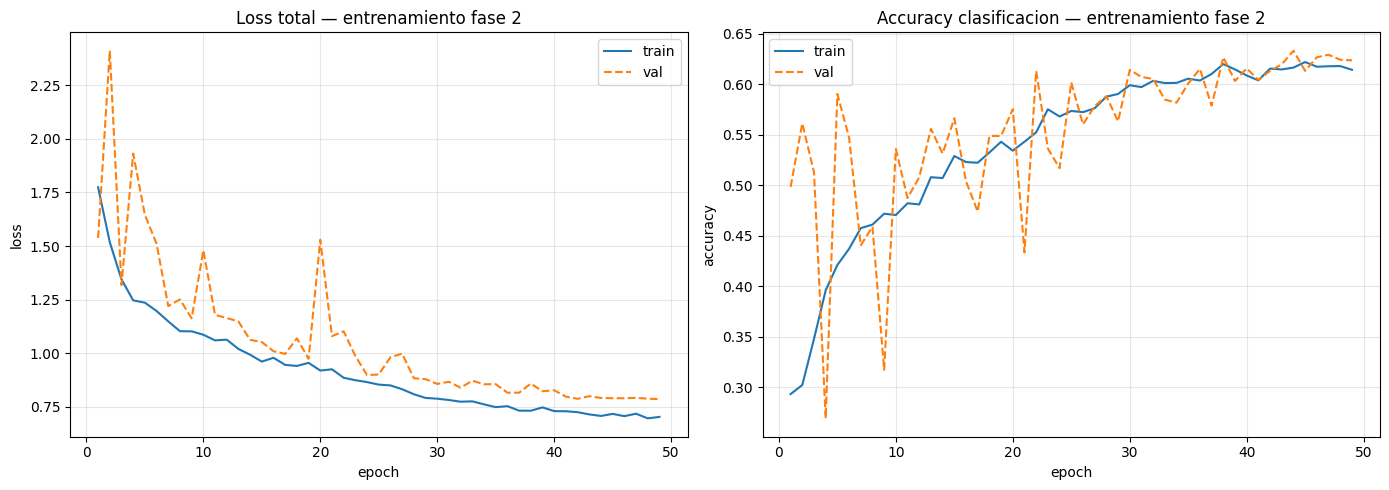

filas del CSV: 2003  (esperado 2003)
NaN en probabilidades: 0
suma softmax por fila en [0.99, 1.01]: True


In [7]:
# Curvas de entrenamiento (train vs val) y chequeo del CSV
hist = pd.read_csv(EXP_DIR / "history.csv")
ep   = np.arange(1, len(hist) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(ep, hist["loss"], label="train")
axes[0].plot(ep, hist["val_loss"], linestyle="--", label="val")
axes[0].set_title("Loss total - entrenamiento fase 2")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].grid(alpha=0.3); axes[0].legend()

acc_key, val_acc_key = "head_disease_accuracy", "val_head_disease_accuracy"
if acc_key in hist.columns:
    axes[1].plot(ep, hist[acc_key], label="train")
    axes[1].plot(ep, hist[val_acc_key], linestyle="--", label="val")
axes[1].set_title("Accuracy clasificacion - entrenamiento fase 2")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout(); plt.savefig(EXP_DIR / "training_curves_fase2.png", dpi=120); plt.show()

probs = df_pred[[f"prob_{c}" for c in class_names]].values
print(f"filas del CSV: {len(df_pred)}  (esperado {len(df_test)})")
print(f"NaN en probabilidades: {int(np.isnan(probs).sum())}")
print(f"suma softmax por fila en [0.99, 1.01]: {bool(np.allclose(probs.sum(axis=1), 1.0, atol=1e-2))}")